<a href="https://colab.research.google.com/github/rrajanala1/hds5210-2023/blob/main/final/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analysing surgical site infections in california with demographics.**

 My project offer's a thorough understanding of the demographic factors linked to SSIs(surgical site infections) in the state With the goal of reducing surgical site infections (SSIs) and addressing health disparities in California. It would also offer useful data for hospital management, public health programs, and policy-making.

 DATA SETS:-

1.[Surgical Site Infections (SSIs) for Operative Procedures in California Hospitals ](https://catalog.data.gov/dataset/surgical-site-infections-ssis-for-operative-procedures-in-california-hospitals-62337) : CSV Format

 2.[Hospitals who did not report surgical procedures, 2022](https://catalog.data.gov/dataset/surgical-site-infections-ssis-for-operative-procedures-in-california-hospitals-62337/resource/ea6614f9-f278-4f84-ab1e-207bff4298b3) : CSV Format

 3.[California Demographics](https://data.census.gov/table/ACSDP1Y2022.DP05?q=demographics%20of%20usa&t=Age%20and%20Sex:Education:Populations%20and%20People&g=040XX00US06,06$0500000,06$1500000,06$8600000&y=2022) : Excel Format

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**Surgical site infections for operative procedures in hospitals of caalifornia.**

California hospitals monitor and report severe surgical injuries (SSIs) resulting from 28 different types of operative procedures to both adult and pediatric patients (under the age of 18). Repair of an abdominal aortic aneurysm; appendix surgery; bile duct, liver, or pancreatic surgery; cardiac surgery; Cesarean section; colon surgery; coronary artery bypass graft with incisions in the chest and donor site; exploratory abdominal surgery (laparotomy); gallbladder surgery; gastric surgery; heart transplant; hip prosthesis; kidney surgery; kidney transplant; knee prosthesis; laminectomy; liver transplant; open reduction of fracture; ovarian surgery; pacemaker surgery; rectal surgery; small bowel surgery; spinal fusion; spleen surgery; thoracic surgery; vaginal hysterectomy.

The SSI data tables show procedure counts, the number of infections observed and anticipated, and information on the statewide and hospital-specific SSI incidence by surgical procedure categories. Based on 2015 national baseline data, NHSN uses procedure-specific risk adjustment logistic regression models to estimate the number of anticipated infections. These models take into account certain patient-level factors and hospital features that have been demonstrated to be important predictors of SSI occurrence.

In [176]:
ssi = pd.read_csv('/content/ca_ssi_adult_odp_2022.csv')
ssi.tail()

,Year,State,County,HAI,Operative_Procedure,Facility_ID,Facility_Name,Hospital_Category_RiskAdjustment,Facility_Type,Procedure_Count,Infections_Reported,Infections_Predicted,SIR,SIR_CI_95_Lower_Limit,SIR_CI_95_Upper_Limit,Comparison,Met_2020_Goal,SIR_2015
6447,2022,California,Los Angeles,Surgical Site Infections (SSI),Ovarian surgery,930001709.0,Memorialcare Miller Children's & Women's Hospi...,Acute Care Hospital,Pediatric,11,0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
6448,2022,California,Los Angeles,Surgical Site Infections (SSI),Small bowel surgery,930001709.0,Memorialcare Miller Children's & Women's Hospi...,Acute Care Hospital,Pediatric,4,0,0.09,NaN,NaN,NaN,NaN,NaN,NaN
6449,2022,California,Los Angeles,Surgical Site Infections (SSI),Spinal fusion,930001709.0,Memorialcare Miller Children's & Women's Hospi...,Acute Care Hospital,Pediatric,4,0,0.06,NaN,NaN,NaN,NaN,NaN,0.0
6450,2022,California,Los Angeles,Surgical Site Infections (SSI),Spleen surgery,930001709.0,Memorialcare Miller Children's & Women's Hospi...,Acute Care Hospital,Pediatric,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN
6451,2022,California,Los Angeles,Surgical Site Infections (SSI),Thoracic surgery,930001709.0,Memorialcare Miller Children's & Women's Hospi...,Acute Care Hospital,Pediatric,2,0,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
ssi.nunique()

Year                                   1
State                                  1
County                                52
HAI                                    1
Operative_Procedure                   58
Facility_ID                          331
Facility_Name                        329
Hospital_Category_RiskAdjustment       2
Facility_Type                          6
Procedure_Count                      880
Infections_Reported                   69
Infections_Predicted                 735
SIR                                  449
SIR_CI_95_Lower_Limit                156
SIR_CI_95_Upper_Limit               1203
Comparison                             3
Met_2020_Goal                          2
SIR_2015                             457
dtype: int64

DROPPING UNNECESSARY COLUMNS

In [178]:
ssi = ssi.drop(columns=['Facility_ID', 'SIR_CI_95_Lower_Limit', 'SIR_CI_95_Upper_Limit',  'Comparison', 'SIR_2015', 'Year', 'State', 'HAI'])
ssi.head()

,County,Operative_Procedure,Facility_Name,Hospital_Category_RiskAdjustment,Facility_Type,Procedure_Count,Infections_Reported,Infections_Predicted,SIR,Met_2020_Goal
0,NaN,STATE OF CALIFORNIA POOLED DATA,NaN,NaN,NaN,635885,3711,4331.08,0.86,No
1,NaN,STATE OF CALIFORNIA POOLED DATA - Abdominal ao...,NaN,NaN,NaN,236,0,1.61,0.00,Yes
2,NaN,STATE OF CALIFORNIA POOLED DATA - Appendix sur...,NaN,NaN,NaN,27959,71,113.45,0.63,Yes
3,NaN,"STATE OF CALIFORNIA POOLED DATA - Bile duct, l...",NaN,NaN,NaN,9402,218,241.61,0.90,No
4,NaN,STATE OF CALIFORNIA POOLED DATA - Cardiac surgery,NaN,NaN,NaN,13876,46,57.39,0.80,No


DROPPING POOLED DATA OF CALIFORNIA

In [179]:
ssi =ssi[ssi['County'].notna()]
ssi.head()

,County,Operative_Procedure,Facility_Name,Hospital_Category_RiskAdjustment,Facility_Type,Procedure_Count,Infections_Reported,Infections_Predicted,SIR,Met_2020_Goal
29,Sacramento,All procedures,Methodist Hospital Of Sacramento,Acute Care Hospital,"Community, 125-250 Beds",1512,7,6.19,1.13,No
30,Sacramento,Appendix surgery,Methodist Hospital Of Sacramento,Acute Care Hospital,"Community, 125-250 Beds",81,1,0.17,NaN,NaN
31,Sacramento,"Bile duct, liver or pancreatic surgery",Methodist Hospital Of Sacramento,Acute Care Hospital,"Community, 125-250 Beds",3,0,0.03,NaN,NaN
32,Sacramento,Cesarean section,Methodist Hospital Of Sacramento,Acute Care Hospital,"Community, 125-250 Beds",387,0,0.38,0.00,Yes
33,Sacramento,Colon surgery,Methodist Hospital Of Sacramento,Acute Care Hospital,"Community, 125-250 Beds",30,1,0.62,1.61,No


DATA TYPES OF COLUMNS

In [180]:
ssi.dtypes

County                               object
Operative_Procedure                  object
Facility_Name                        object
Hospital_Category_RiskAdjustment     object
Facility_Type                        object
Procedure_Count                       int64
Infections_Reported                   int64
Infections_Predicted                float64
SIR                                 float64
Met_2020_Goal                        object
dtype: object

Let's start by examining the overall count for each category of Procedure.

In [181]:
procedures = ssi[ssi['Operative_Procedure'] != 'All procedures']
county_procedure= procedures.groupby(['Operative_Procedure']).agg({'Procedure_Count': 'sum'}).sort_values(by = 'Procedure_Count')
county_procedure

,Procedure_Count
Operative_Procedure,
Abdominal aortic aneurysm repair,236
Heart transplant,458
Liver transplant,994
"Coronary bypass,chest incision only",1654
Spleen surgery,1761
"Hysterectomy, vaginal",2230
Kidney transplant,2577
Rectal surgery,6314
Kidney surgery,6969


ploting to visualize the data with with bar charts.

In [182]:
from matplotlib.colors import ListedColormap

def bar_plot(df, plot_type,colour,size, xtitle, ytitle, title):
  """
  (dataframe, string, string, string)

  This is a very simple function. It takes in a two columned data frame as an input. One numerical column (count in our use cases) and one column with names.
  We will also be able to give the x-axis title, y-axis title and the plot's title as input to the function.
  And we have the option to draw a vertical or horizontal bar chart.
  then finally, we can also specifiy the figure size, as we will be drawing both vertical and horizontal charts,
  having the ability to change the size is crucial step.
  """

  df.plot(kind = plot_type, figsize = size, color = colour)
  plt.xlabel(xtitle)
  plt.ylabel(ytitle)
  plt.title(title)
  plt.show()

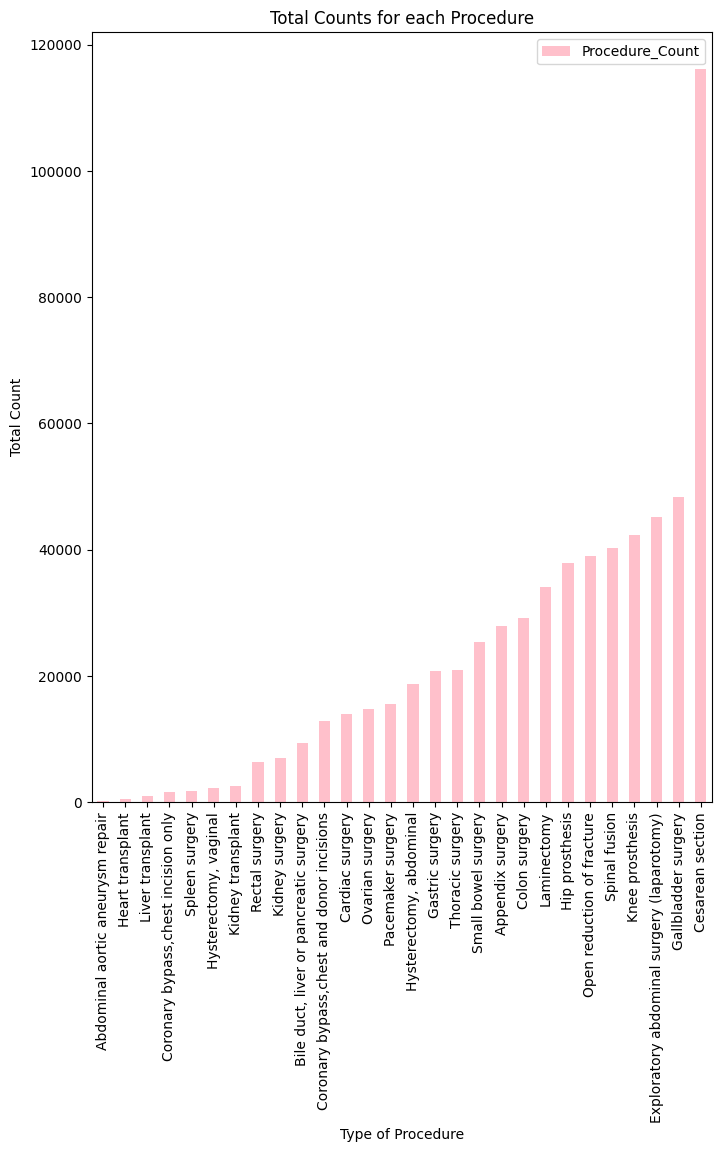

In [183]:
bar_plot(county_procedure, 'bar','pink', (8,10), 'Type of Procedure', 'Total Count', 'Total Counts for each Procedure')

from the above plot ,the most common  is cesarean section.
gallbladder,laprotomy,knee prosthesis are top 5 most common and abdominal aortic aneurysm repair is least common procedure.

NOW , we see the types of facilities and ther count.

In [184]:
all_procedure = ssi[ssi['Operative_Procedure'] == 'All procedures']
facility = all_procedure.groupby('Facility_Type')['Facility_Name'].count().sort_values(ascending = False)

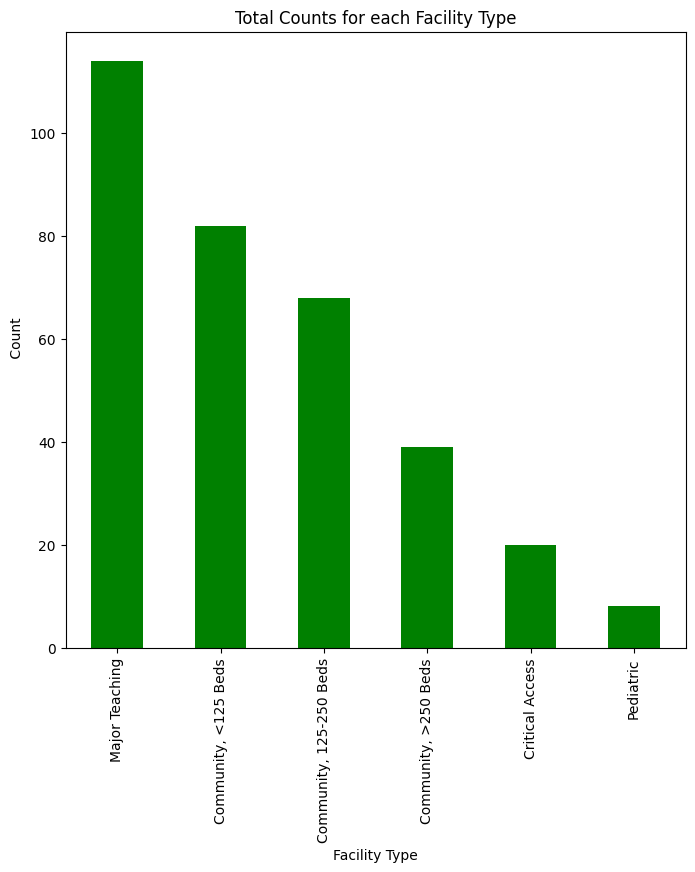

In [185]:
bar_plot(facility, 'bar', 'green' ,(8,8),  'Facility Type', ' Count', 'Total Counts for each Facility Type')

We can see that there are more than 100 Major Teaching Facilities from the plot. These are establishments that collaborate with nursing and medical schools.

It is followed by small community Hospitals (with less than 125 beds), then by medium community hospitals (less than 250 beds), and that is followed by Large community hospitals (over the 250 beds).

Among facilities with fewer than 20, Critical Access and Pediatric facilities rank lowest.

Additionally, a pediatric hospital is one that only provides care for children and newborns.

In [186]:
category = ssi.groupby('Hospital_Category_RiskAdjustment')['Facility_Name'].count().sort_values(ascending = False)
category

Hospital_Category_RiskAdjustment
Acute Care Hospital         6193
Critical Access Hospital     230
Name: Facility_Name, dtype: int64

Here from the above observation,
most of the hospitals are acute care hospitals and few are crtical access hospitals.

In [187]:
# AVERAGE number of surgeries each type of facility do.
facility_avg = all_proc.groupby('Facility_Type')['Procedure_Count'].mean().sort_values(ascending = False)

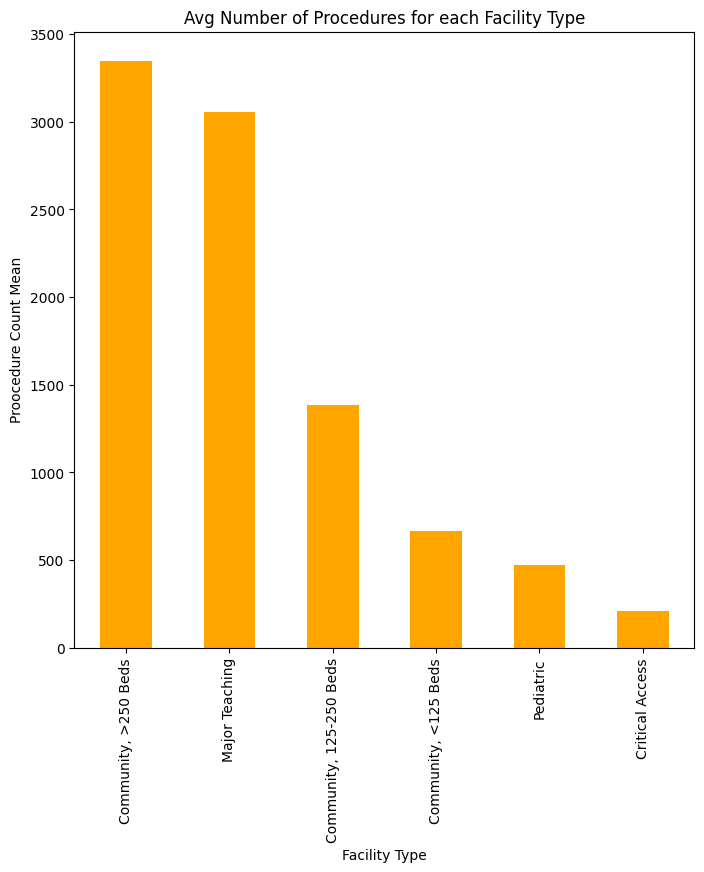

In [188]:
bar_plot(facility_avg, 'bar', 'orange' ,(8,8),  'Facility Type', 'Proocedure Count Mean', 'Avg Number of Procedures for each Facility Type')

Large community hospitals and major teaching have over 3000 procedures and medium comminity has under 1500 procedures.

MOST COMMON COUNTY WITH PROCEDUES.

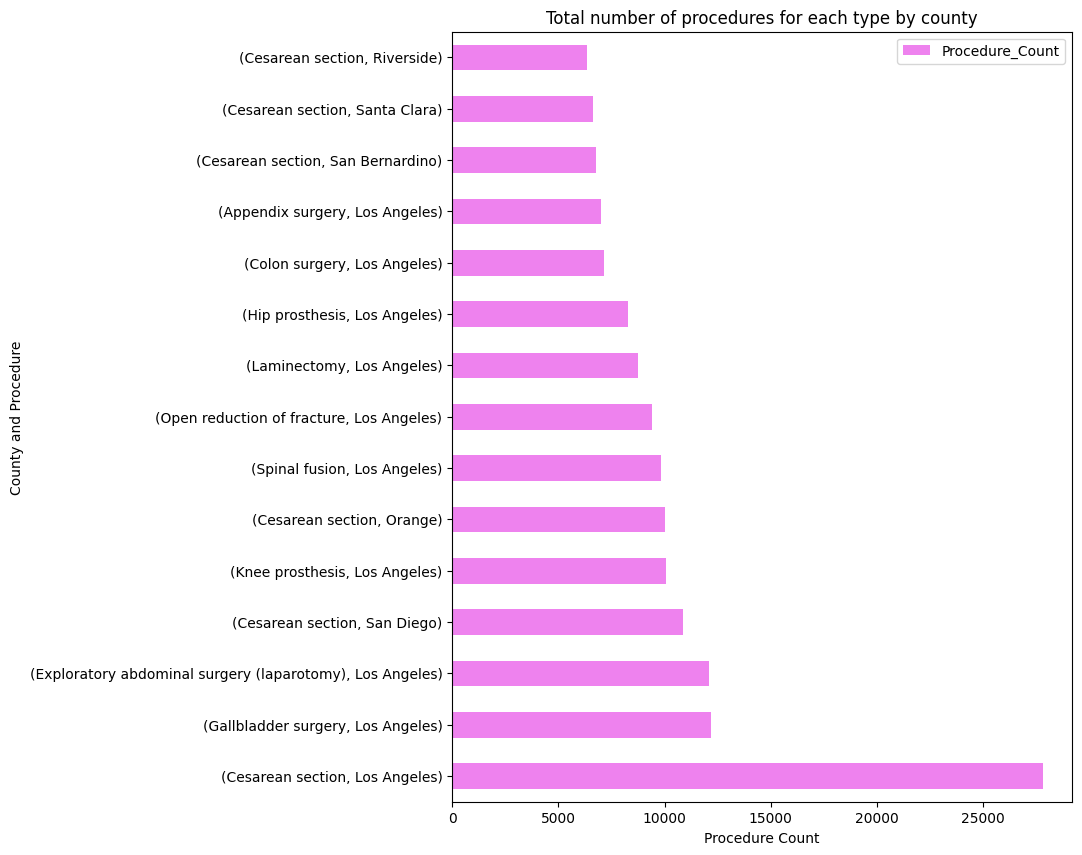

In [189]:
county_procedure_sum = procedures.groupby(['Operative_Procedure', 'County']).agg({'Procedure_Count': 'sum'}).sort_values(by = 'Procedure_Count',ascending = False)
bar_plot(county_procedure_sum.head(15), 'barh', 'violet' ,(8,10),  'Procedure Count', 'County and Procedure', 'Total number of procedures for each type by county')

Los Angeles is the most populous county in California by far

Now I do the same grouping, but this time I will use the average process count rather than the sum. Sum will have a bias in favor of Los Angeles due to its disproportionately higher population.

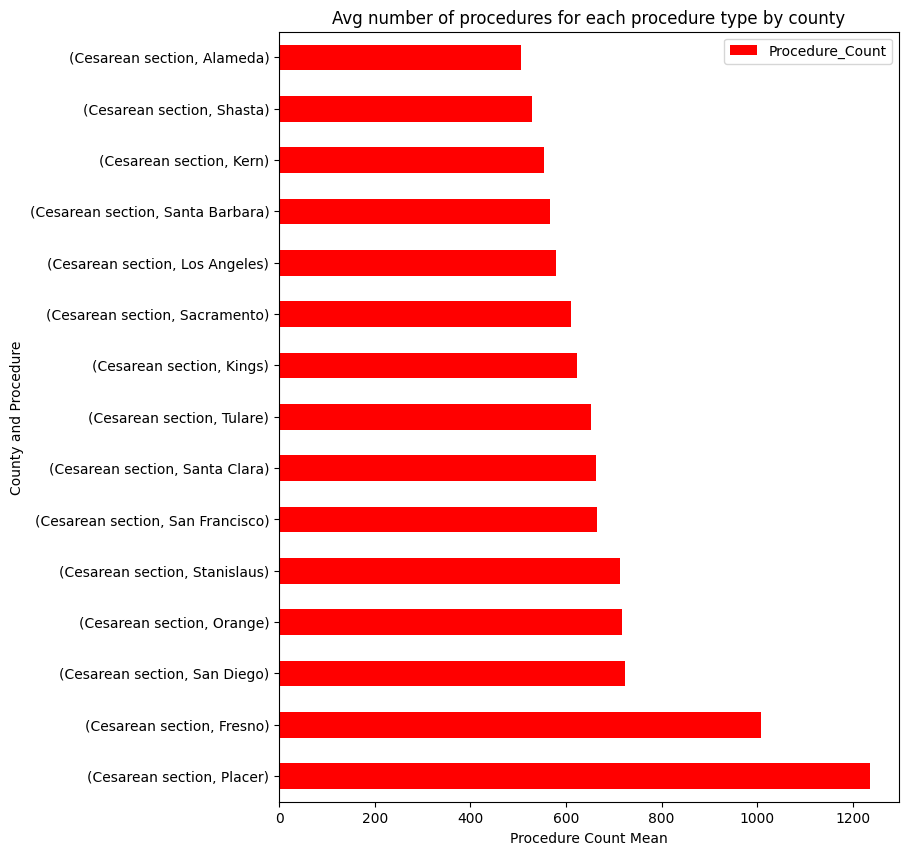

In [190]:
county_procedure_avg = procedures.groupby(['Operative_Procedure', 'County']).agg({'Procedure_Count': 'mean'}).sort_values(by = 'Procedure_Count',ascending = False)
bar_plot(county_procedure_avg.head(15), 'barh', 'red' ,(8,10),  'Procedure Count Mean', 'County and Procedure', 'Avg number of procedures for each procedure type by county')

Here from the graph we came to know that cesarean section is common and placer county is the highest avg procedures per facility.

now let us see the placer county

In [191]:
placer = procedures[procedures['County'] == 'Placer']
placer[placer['Operative_Procedure'] == 'Cesarean section']

,County,Operative_Procedure,Facility_Name,Hospital_Category_RiskAdjustment,Facility_Type,Procedure_Count,Infections_Reported,Infections_Predicted,SIR,Met_2020_Goal
365,Placer,Cesarean section,Sutter Roseville Medical Center,Acute Care Hospital,"Community, >250 Beds",656,2,0.63,3.18,No
597,Placer,Cesarean section,Kaiser Foundation Hospital - Roseville,Acute Care Hospital,Major Teaching,1813,9,7.30,1.23,No


we came to know that only two facilites doing 'cesarean section'

-->FACILITES WHERE NO SURGERIES WHERE PERFORMED.

From January 1, 2022, to December 31, 2022, the hospitals in California included in this table did not carry out any of the 28 reportable procedures.

In [192]:
no_surgery = pd.read_csv('/content/cdph_ssi_nosurgfac_odp_2022.csv')
no_surgery.head()

,Year,State,County,HAI,Facility_ID,Facility_Name,Facility_Type,Number_Months_Expected,Notes
0,2022,California,Stanislaus,Surgical Site Infections (SSI),30000129,Central Valley Specialty Hospital,Long-Term Acute Care,12,No surgeries in the 28 surgical procedure cate...
1,2022,California,Sacramento,Surgical Site Infections (SSI),30000907,Vibra Hospital Of Sacramento,Long-Term Acute Care,12,No surgeries in the 28 surgical procedure cate...
2,2022,California,Fresno,Surgical Site Infections (SSI),40000096,Coalinga Regional Medical Center,"Community, <125 Beds",12,No surgeries in the 28 surgical procedure cate...
3,2022,California,Mariposa,Surgical Site Infections (SSI),40000105,John C. Fremont Healthcare District,Critical Access,12,No surgeries in the 28 surgical procedure cate...
4,2022,California,Fresno,Surgical Site Infections (SSI),40000613,San Joaquin Valley Rehabilitation Hospital,Free-Standing Rehabilitation,12,No surgeries in the 28 surgical procedure cate...


In [193]:
no_surgery.nunique()

Year                       1
State                      1
County                    26
HAI                        1
Facility_ID               64
Facility_Name             64
Facility_Type              8
Number_Months_Expected     1
Notes                      1
dtype: int64

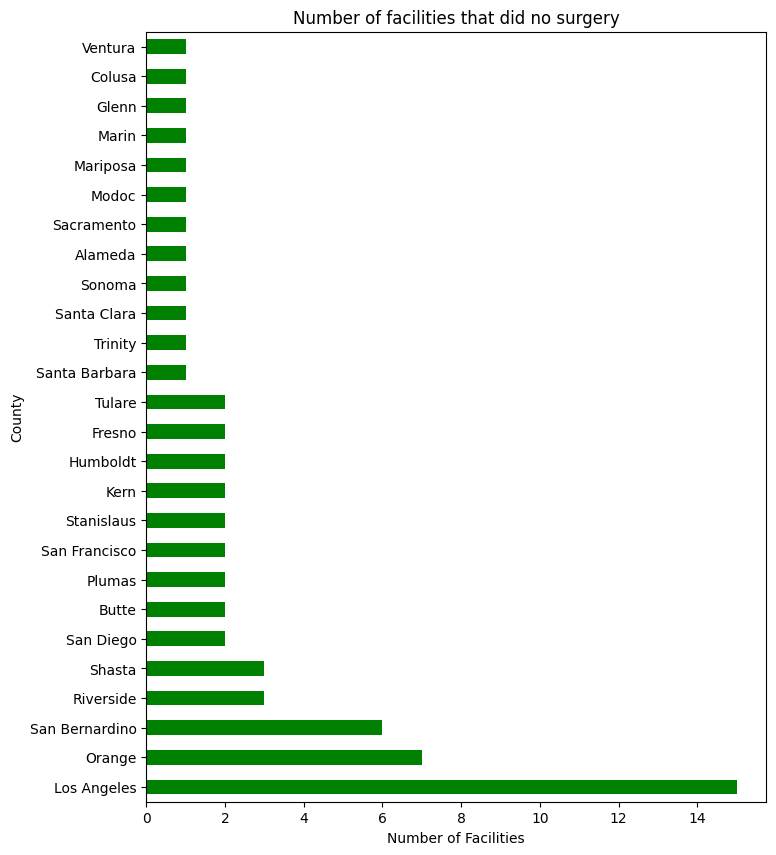

In [194]:
no_surgery_county = no_surgery.groupby('County')['Facility_ID'].count().sort_values(ascending = False)
bar_plot(no_surgery_county, 'barh', 'green' ,(8,10),  'Number of Facilities', 'County', 'Number of facilities that did no surgery')

los angeles is the heighest with number of facilities done no sugery.

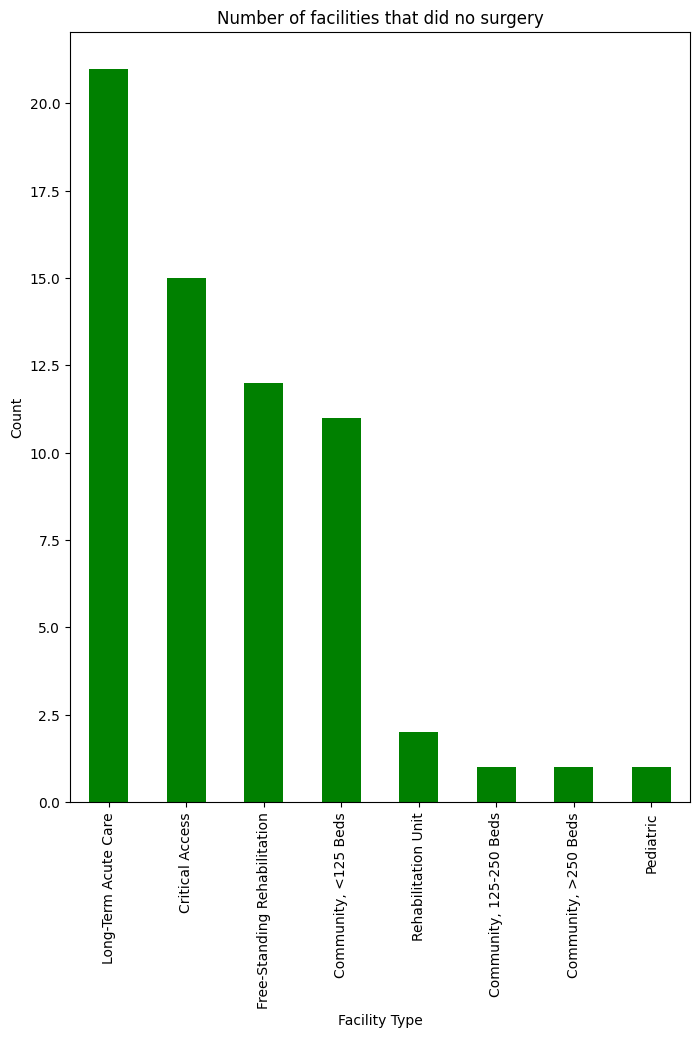

In [195]:
no_surgery_facility = no_surgery.groupby('Facility_Type')['Facility_ID'].count().sort_values(ascending = False)
bar_plot(no_surgery_facility, 'bar', 'green' ,(8,10),  'Facility Type', 'Count', 'Number of facilities that did no surgery')

While general hospitals may have more surgical facilities, long-term acute care facilities may concentrate more on medical management and rehabilitation. Maybe that's why the plot developed.

Additionally, Rehabilitation Centers are displayed in the chart. It makes logical that they are here because they are also incapable of doing procedures.

CALIFORNIA DEMOGRAPHICS DATA.

In [196]:
xls = pd.ExcelFile('/content/ACSCP1Y2022.CP05-2023-12-10T230536.xlsx')
# our data is sheet called 'Data'
demo = pd.read_excel(xls, 'Data')

In [197]:
demo.head()

,Unnamed: 0,United States,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 387,"Yuba County, California",Unnamed: 389,Unnamed: 390,Unnamed: 391,Unnamed: 392,Unnamed: 393,Unnamed: 394,Unnamed: 395,Unnamed: 396
0,Label,2022 Estimate,2021 Estimate,2022 - 2021 Statistical Significance,2020 Estimate,2022 - 2020 Statistical Significance,2019 Estimate,2022 - 2019 Statistical Significance,2018 Estimate,2022 - 2018 Statistical Significance,...,2022 - 2018 Statistical Significance,2022 Estimate,2021 Estimate,2022 - 2021 Statistical Significance,2020 Estimate,2022 - 2020 Statistical Significance,2019 Estimate,2022 - 2019 Statistical Significance,2018 Estimate,2022 - 2018 Statistical Significance
1,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total population,"333,287,562","331,893,745",c,(X),NaN,"328,239,523",c,"327,167,439",c,...,c,"84,310","83,421",c,(X),NaN,"78,668",c,"78,041",c
3,Male,49.6%,49.5%,*,(X),NaN,49.2%,*,49.2%,*,...,NaN,50.2%,50.0%,NaN,(X),NaN,50.7%,NaN,51.0%,NaN
4,Female,50.4%,50.5%,*,(X),NaN,50.8%,*,50.8%,*,...,NaN,49.8%,50.0%,NaN,(X),NaN,49.3%,NaN,49.0%,NaN


I want drop all the columns with Unnamed in their name, these are not required, the data we needed is 2022 estimate, which is under the name of the county.

In [198]:
#  dropping all columns except one
demo = demo.rename(columns = {'Unnamed: 0': 'Data'})

droppable = []

# Only unnamed columns have ':' in them so we will use that to detect them.
for x in demo.columns:
  if ':' in x:
    droppable.append(x)

demo = demo.drop(columns = droppable)

# Let's also dro the first 2 rows


demo = demo.drop(0)

demo = demo.drop(1)
#Transposing the Data so as to have the Counties as rows.

demo_transpose = demo.T
demo_transpose.columns = demo_transpose.iloc[0]
demo_transpose = demo_transpose.drop('Data')
demo_transpose = demo_transpose.reset_index()

demo_transpose.head()

Data,index,Total population,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,Native Hawaiian and Other Pacific Islander alone,Some Other Race alone,Two or More Races,Two races including Some Other Race,"Two races excluding Some Other Race, and three or more races",Total housing units,"CITIZEN, VOTING AGE POPULATION","Citizen, 18 and over population",Male,Female
0,United States,"333,287,562",49.6%,50.4%,98.3,5.5%,5.9%,6.4%,6.5%,6.7%,...,0.2%,0.6%,4.3%,1.0%,3.3%,"143,772,895",NaN,"241,228,116",48.9%,51.1%
1,California,"39,029,342",50.1%,49.9%,100.2,5.4%,5.9%,6.5%,6.6%,6.8%,...,0.3%,0.6%,4.3%,0.8%,3.5%,"14,627,041",NaN,"26,078,922",49.4%,50.6%
2,"Alameda County, California","1,628,997",49.7%,50.3%,98.9,5.1%,5.4%,5.5%,5.8%,5.7%,...,0.6%,0.7%,5.7%,0.8%,4.9%,"633,865",NaN,"1,081,143",49.0%,51.0%
3,"Butte County, California","207,303",49.9%,50.1%,99.7,5.2%,6.0%,5.2%,7.1%,11.2%,...,0.4%,0.9%,6.5%,2.6%,3.9%,"92,362",NaN,"159,338",49.7%,50.3%
4,"Contra Costa County, California","1,156,966",49.2%,50.8%,97.0,5.3%,6.0%,6.3%,6.5%,5.8%,...,0.5%,1.0%,5.7%,0.9%,4.8%,"430,051",NaN,"792,345",48.7%,51.3%


Removing pooled data and renaming index as county

In [199]:
# removing pooled data.
demo_transpose = demo_transpose.drop(0)
demo_transpose = demo_transpose.drop(1)

#renaming index as 'County'
demo_transpose = demo_transpose.rename(columns = {'index': 'County'})
demo_transpose.head()

Data,County,Total population,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,Native Hawaiian and Other Pacific Islander alone,Some Other Race alone,Two or More Races,Two races including Some Other Race,"Two races excluding Some Other Race, and three or more races",Total housing units,"CITIZEN, VOTING AGE POPULATION","Citizen, 18 and over population",Male,Female
2,"Alameda County, California","1,628,997",49.7%,50.3%,98.9,5.1%,5.4%,5.5%,5.8%,5.7%,...,0.6%,0.7%,5.7%,0.8%,4.9%,"633,865",NaN,"1,081,143",49.0%,51.0%
3,"Butte County, California","207,303",49.9%,50.1%,99.7,5.2%,6.0%,5.2%,7.1%,11.2%,...,0.4%,0.9%,6.5%,2.6%,3.9%,"92,362",NaN,"159,338",49.7%,50.3%
4,"Contra Costa County, California","1,156,966",49.2%,50.8%,97.0,5.3%,6.0%,6.3%,6.5%,5.8%,...,0.5%,1.0%,5.7%,0.9%,4.8%,"430,051",NaN,"792,345",48.7%,51.3%
5,"El Dorado County, California","192,646",50.1%,49.9%,100.6,4.3%,5.8%,5.3%,5.8%,3.9%,...,0.1%,0.8%,4.7%,0.5%,4.2%,"94,831",NaN,"145,760",50.0%,50.0%
6,"Fresno County, California","1,015,190",50.3%,49.7%,101.3,6.9%,7.4%,8.5%,7.6%,7.2%,...,0.1%,0.6%,3.1%,0.5%,2.6%,"345,476",NaN,"632,703",49.0%,51.0%


cleanthe county names:


In [200]:
# clean the county names:
demo_transpose['County'] = demo_transpose['County'].str.replace(' County, California', '')

In [201]:
demo_transpose.columns

Index(['County', 'Total population', 'Male', 'Female',
       'Sex ratio (males per 100 females)', 'Under 5 years', '5 to 9 years',
       '10 to 14 years', '15 to 19 years', '20 to 24 years', '25 to 34 years',
       '35 to 44 years', '45 to 54 years', '55 to 59 years', '60 to 64 years',
       '65 to 74 years', '75 to 84 years', '85 years and over',
       'Median age (years)', 'Under 18 years', '16 years and over',
       '18 years and over', '21 years and over', '62 years and over',
       '65 years and over', '18 years and over', 'Male', 'Female',
       'Sex ratio (males per 100 females)', '65 years and over', 'Male',
       'Female', 'Sex ratio (males per 100 females)', 'RACE',
       'Total population', 'One race', 'Two or More Races', 'One race',
       'White', 'Black or African American',
       'American Indian and Alaska Native', 'Cherokee tribal grouping',
       'Chippewa tribal grouping', 'Navajo tribal grouping',
       'Sioux tribal grouping', 'Asian', 'Asian Indian',

As we can see there are way too many columns with same names, so first let's make  the dataframe to contain only the first few columns.

In [202]:
sample = demo_transpose.iloc[:, 0:25]
sample.columns

Index(['County', 'Total population', 'Male', 'Female',
       'Sex ratio (males per 100 females)', 'Under 5 years', '5 to 9 years',
       '10 to 14 years', '15 to 19 years', '20 to 24 years', '25 to 34 years',
       '35 to 44 years', '45 to 54 years', '55 to 59 years', '60 to 64 years',
       '65 to 74 years', '75 to 84 years', '85 years and over',
       'Median age (years)', 'Under 18 years', '16 years and over',
       '18 years and over', '21 years and over', '62 years and over',
       '65 years and over'],
      dtype='object', name='Data')

In [203]:
#cleaning ofthe population
sample['Total population'] = sample['Total population'].str.replace(',','').astype(int)
sample.head()

Data,County,Total population,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,65 to 74 years,75 to 84 years,85 years and over,Median age (years),Under 18 years,16 years and over,18 years and over,21 years and over,62 years and over,65 years and over
2,Alameda,1628997,49.7%,50.3%,98.9,5.1%,5.4%,5.5%,5.8%,5.7%,...,9.1%,4.7%,1.9%,39.4,19.5%,82.8%,80.5%,76.9%,19.1%,15.7%
3,Butte,207303,49.9%,50.1%,99.7,5.2%,6.0%,5.2%,7.1%,11.2%,...,11.1%,5.3%,2.2%,36.7,20.0%,82.4%,80.0%,74.2%,22.7%,18.6%
4,Contra Costa,1156966,49.2%,50.8%,97.0,5.3%,6.0%,6.3%,6.5%,5.8%,...,10.0%,5.3%,2.1%,40.5,21.7%,81.1%,78.3%,74.6%,21.2%,17.4%
5,El Dorado,192646,50.1%,49.9%,100.6,4.3%,5.8%,5.3%,5.8%,3.9%,...,14.3%,7.3%,2.1%,46.1,19.2%,83.2%,80.8%,78.0%,28.0%,23.7%
6,Fresno,1015190,50.3%,49.7%,101.3,6.9%,7.4%,8.5%,7.6%,7.2%,...,7.6%,3.8%,1.5%,33.4,27.7%,75.6%,72.3%,68.3%,16.1%,12.9%


Creating of a custom function to convert columns with %'s into total number, by dividing the percentage by 100 and multiplying by total population

In [204]:
def convert_perc_to_number(df, col):
  """
  This function takes a dataframe and it's column as inputs
  It strips '%' from the end of th data and converts it into float.
  And then it converts the percentage into raw number by dividing by 100 and multiplying with total population
  """
  df[col] = df[col].str.rstrip('%').astype('float') / 100.0 * df['Total population']
  df[col] = df[col].astype('int')
  return df[col]

In [205]:
cols = [ 'Male', 'Female', 'Under 5 years', '5 to 9 years',
       '10 to 14 years', '15 to 19 years', '20 to 24 years', '25 to 34 years',
       '35 to 44 years', '45 to 54 years', '55 to 59 years', '60 to 64 years',
       '65 to 74 years', '75 to 84 years', '85 years and over', 'Under 18 years', '16 years and over',
       '18 years and over', '21 years and over', '62 years and over',
       '65 years and over']
for col in cols:
  sample[col] = convert_perc_to_number(sample, col)
sample.head()

Data,County,Total population,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,65 to 74 years,75 to 84 years,85 years and over,Median age (years),Under 18 years,16 years and over,18 years and over,21 years and over,62 years and over,65 years and over
2,Alameda,1628997,809611,819385,98.9,83078,87965,89594,94481,92852,...,148238,76562,30950,39.4,317654,1348809,1311342,1252698,311138,255752
3,Butte,207303,103444,103858,99.7,10779,12438,10779,14718,23217,...,23010,10987,4560,36.7,41460,170817,165842,153818,47057,38558
4,Contra Costa,1156966,569227,587738,97.0,61319,69417,72888,75202,67104,...,115696,61319,24296,40.5,251061,938299,905904,863096,245276,201312
5,El Dorado,192646,96515,96130,100.6,8283,11173,10210,11173,7513,...,27548,14063,4045,46.1,36988,160281,155657,150263,53940,45657
6,Fresno,1015190,510640,504549,101.3,70048,75124,86291,77154,73093,...,77154,38577,15227,33.4,281207,767483,733982,693374,163445,130959


In [206]:
sample = sample.sort_values(by = 'Total population',ascending = False) #The most populated counties
sample.head(10)

Data,County,Total population,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,65 to 74 years,75 to 84 years,85 years and over,Median age (years),Under 18 years,16 years and over,18 years and over,21 years and over,62 years and over,65 years and over
12,Los Angeles,9721138,4821684,4899453,98.6,486056,534662,602710,602710,651316,...,855460,437451,184701,38.2,1983112,7981054,7738025,7378343,1817852,1477612
26,San Diego,3276208,1661037,1615170,102.8,180191,186743,196572,206401,239163,...,294858,157257,55695,37.3,678175,2673385,2598032,2457156,622479,507812
20,Orange,3151184,1566138,1585045,98.6,163861,173315,198524,207978,207978,...,293060,163861,63023,39.5,655446,2577668,2495737,2369690,633387,516794
22,Riverside,2473902,1244372,1229529,101.1,141012,158329,180594,178120,170699,...,215229,126169,37108,36.8,593736,1954382,1880165,1771313,460145,378507
25,San Bernardino,2193656,1101215,1092440,100.9,138200,144781,173298,160136,164524,...,168911,78971,26323,34.4,557188,1702277,1636467,1544333,342210,274207
32,Santa Clara,1870945,956052,914892,104.6,95418,101031,112256,117869,119740,...,155288,87934,37418,38.3,377930,1539787,1493014,1421918,349866,282512
2,Alameda,1628997,809611,819385,98.9,83078,87965,89594,94481,92852,...,148238,76562,30950,39.4,317654,1348809,1311342,1252698,311138,255752
23,Sacramento,1584169,782579,801589,97.5,93465,99802,102970,101386,98218,...,144159,71287,28515,37.3,359606,1265751,1224562,1167532,297823,243962
4,Contra Costa,1156966,569227,587738,97.0,61319,69417,72888,75202,67104,...,115696,61319,24296,40.5,251061,938299,905904,863096,245276,201312
6,Fresno,1015190,510640,504549,101.3,70048,75124,86291,77154,73093,...,77154,38577,15227,33.4,281207,767483,733982,693374,163445,130959


## **MERGING**

In [207]:
# Total procedure counts for counties.
county_sum = procedures.groupby('County').agg({'Procedure_Count': 'sum'}).sort_values(by = 'Procedure_Count',ascending = False)

In [208]:
county_sum.head()

,Procedure_Count
County,
Los Angeles,157043
San Diego,60861
Orange,58900
Riverside,34801
Santa Clara,34283


In [209]:
# population for each county.
popul = sample[['County', 'Total population']]
popul.head()

Data,County,Total population
12,Los Angeles,9721138
26,San Diego,3276208
20,Orange,3151184
22,Riverside,2473902
25,San Bernardino,2193656


In [210]:
population_procedure = pd.merge(county_sum, popul, on  = 'County')
population_procedure.head()

,County,Procedure_Count,Total population
0,Los Angeles,157043,9721138
1,San Diego,60861,3276208
2,Orange,58900,3151184
3,Riverside,34801,2473902
4,Santa Clara,34283,1870945


In [211]:
population_procedure['Standardized'] = population_procedure['Procedure_Count'] / population_procedure['Total population']  * 100
population_procedure = population_procedure.sort_values(by = 'Standardized', ascending = False)
temp = population_procedure[['County', 'Standardized']]
temp.head(10)

,County,Standardized
8,San Francisco,2.836337
14,Placer,2.727564
22,Shasta,2.602111
29,Yuba,2.510971
12,Stanislaus,2.349463
7,Fresno,2.299964
15,Santa Barbara,2.182333
23,Butte,2.173630
25,Napa,2.117647
6,Sacramento,1.970181


-->A more complex picture of the data is obtained by dividing the Procedure_count by the county's population in order to transform it into a standard format.

Due its advantage in large population, Los Angeles has consistently ranked highest on our lists thus far.

We can now state that San Francisco has an average of more procedures because to this standardized data. In San Francisco, there are roughly 2.8 procedures performed for every 100 persons.

In [212]:
temp.tail(10)

,County,Standardized
28,Marin,0.995243
32,Imperial,0.945650
26,Merced,0.944092
37,Tehama,0.933405
33,Yolo,0.760417
35,El Dorado,0.741775
40,Lake,0.595386
41,San Benito,0.522352
39,Sutter,0.437550
38,Madera,0.278929


Madera has the lowest number of procedures per 100 people,

 it has about 2.8 procedures for 1000 people. That is, 10 times less than San Francisco.

In [213]:
temp[temp['County'] == 'Los Angeles']

,County,Standardized
0,Los Angeles,1.61548


 los angeles has only 1.6 procedures per every 100 people.

In [214]:
count = county_procedure_avg.reset_index()
count[count['County'] == 'Madera']

,Operative_Procedure,County,Procedure_Count
210,Cesarean section,Madera,129.0
594,Gallbladder surgery,Madera,39.5
658,Exploratory abdominal surgery (laparotomy),Madera,30.0
771,Hip prosthesis,Madera,16.0
774,Appendix surgery,Madera,15.5
824,Ovarian surgery,Madera,12.0
842,Colon surgery,Madera,11.0
866,Open reduction of fracture,Madera,9.0
877,Thoracic surgery,Madera,8.5
922,Knee prosthesis,Madera,6.0


In [215]:
pop[pop['County'] == 'Madera']

Data,County,Total population
13,Madera,160256


In [216]:
madera = ssi[ssi['County'] == 'Madera']
madera.nunique()

County                               1
Operative_Procedure                 20
Facility_Name                        2
Hospital_Category_RiskAdjustment     1
Facility_Type                        2
Procedure_Count                     18
Infections_Reported                  1
Infections_Predicted                18
SIR                                  1
Met_2020_Goal                        1
dtype: int64

In [217]:
madera['Facility_Name'].unique()

array(['Madera Community Hospital', "Valley Children's Hospital"],
      dtype=object)

There are 160,000 people living in Madera. However, as of 2022, there are just two facilities that have done surgeries. It is  possible that Madera resident's travel beyond the county for medical care.

Considering that there are just two surgical facilities—a children's hospital is one of them.

***let's check the number of facilities each county has.***

In [218]:
county_facilities = all_proc.groupby('County')['Facility_Name'].count().sort_values(ascending = False)
county_facilities = county_facilities.reset_index()
county_facilities.head()

,County,Facility_Name
0,Los Angeles,75
1,Orange,26
2,San Diego,20
3,San Bernardino,18
4,Riverside,17


In [219]:
county_facilities = county_facilities.rename(columns = {'Facility_Name': 'Facility_Count'})

## **second merge**

In [220]:
#second merge

facilities_per_person = pd.merge(county_facilities, pop, on = 'County')
facilities_per_person.head()

,County,Facility_Count,Total population
0,Los Angeles,75,9721138
1,Orange,26,3151184
2,San Diego,20,3276208
3,San Bernardino,18,2193656
4,Riverside,17,2473902


In [221]:
# creat a column to see how many facilities each county has per 100,000 people.
facilities_per_person['Facility_per_100k'] = facilities_per_person['Facility_Count'] * 100000 /facilities_per_person['Total population']
facilities_per_person = facilities_per_person.sort_values(by = 'Facility_per_100k', ascending = False)

In [222]:
facilities_per_person.head(10)

,County,Facility_Count,Total population,Facility_per_100k
25,Mendocino,3,89783,3.341390
32,Lake,2,68191,2.932938
26,Humboldt,3,135010,2.222058
36,Nevada,2,102293,1.955168
37,Tehama,1,65245,1.532684
33,Napa,2,134300,1.489203
40,San Benito,1,67579,1.479750
19,San Luis Obispo,4,282013,1.418374
7,San Francisco,11,808437,1.360650
31,Madera,2,160256,1.248003


The highest ratio of facilities to population is seen in Mendocino County. However, the list indicates that the population of each county really is low.

In [223]:
facilities_per_person.tail(10)

,County,Facility_Count,Total population,Facility_per_100k
0,Los Angeles,75,9721138,0.771515
23,Placer,3,417772,0.718095
12,Contra Costa,8,1156966,0.691464
28,Merced,2,290014,0.689622
4,Riverside,17,2473902,0.687174
39,Kings,1,152981,0.653676
22,Tulare,3,477544,0.628214
2,San Diego,20,3276208,0.610462
6,Santa Clara,11,1870945,0.587938
9,Sacramento,9,1584169,0.568121


Let's see a list of only the Large counties, with over 1 million population

In [224]:
facilities_per_person[facilities_per_person['Total population'] > 1000000]

,County,Facility_Count,Total population,Facility_per_100k
1,Orange,26,3151184,0.825087
3,San Bernardino,18,2193656,0.820548
5,Alameda,13,1628997,0.798037
11,Fresno,8,1015190,0.788030
0,Los Angeles,75,9721138,0.771515
12,Contra Costa,8,1156966,0.691464
4,Riverside,17,2473902,0.687174
2,San Diego,20,3276208,0.610462
6,Santa Clara,11,1870945,0.587938
9,Sacramento,9,1584169,0.568121


Thus, the ratio is nearly the same in all of the large counties. Although this may appear to be less than what we observed for the smaller counties, I think it's important to consider population density. Because dense populations tend to be larger, people may not need to drive as far to a facility in highly populated counties.

## CONCLUSION:-
We have examined surgical procedure data from California for this project and  the number of procedures performed in each county, the number of facilities, and various other facts.

To provide a more detailed picture, we have examined this data from a demographic perspective. Numerous analytical and informative opportunities were presented by merging the surgical site infections (SSIs) dataset from California hospitals with the the state's demographics dataset.

This project would provide a comprehensive understanding of the demographic factors associated with surgical site infections in California, offering valuable insights for public health efforts, hospital management, and policy-making.The combination of the demographics dataset  with the surgical site infections (SSIs) dataset from California hospitals presents several analytical and insightful opportunities.

GOOGLE DRIVE LINK FOR DATA SETS USED.

https://drive.google.com/drive/folders/1CY3QsG-8eQTDbcOq9xVB0aBipguqE7dM?usp=sharing  